# Title

In [1]:
# Import necessary libraries
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
import pandas as pd
import json
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

In [3]:
# Parameters
IMG_SIZE = (224, 224)  # ResNet input size
FRAME_COUNT = 30       # Number of frames per video
BATCH_SIZE = 16
EPOCHS = 5

In [4]:
# Step 1: Load and preprocess video data from DFDC
def extract_frames(video_path, num_frames=FRAME_COUNT):
    """Extract a fixed number of frames from a video."""
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames == 0:
        return None
    frame_indices = np.linspace(0, total_frames-1, num_frames, dtype=int)
    
    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame = cv2.resize(frame, IMG_SIZE)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = frame / 255.0  # Normalize to [0, 1]
            frames.append(frame)
    cap.release()
    
    if len(frames) < num_frames:
        frames.extend([np.zeros((IMG_SIZE[0], IMG_SIZE[1], 3))] * (num_frames - len(frames)))
    return np.array(frames)

def load_dfdc_dataset(data_dir, metadata_file, max_videos=100):
    """Load a subset of DFDC videos with labels from metadata."""
    with open(metadata_file, 'r') as f:
        metadata = json.load(f)
    
    X, y = [], []
    video_dir = os.path.join(data_dir, 'train_sample_videos')
    video_files = list(metadata.keys())[:max_videos]  # Limit for faster testing
    
    for video_file in video_files:
        video_path = os.path.join(video_dir, video_file)
        if os.path.exists(video_path):
            frames = extract_frames(video_path)
            if frames is not None:
                X.append(frames)
                label = 1 if metadata[video_file]['label'] == 'FAKE' else 0
                y.append(label)
    
    return np.array(X), np.array(y)
# DFDC dataset path in Kaggle
DATA_DIR = '/kaggle/input/deepfake-detection-challenge/'
METADATA_FILE = os.path.join(DATA_DIR, 'train_sample_videos/metadata.json')
X, y = load_dfdc_dataset(DATA_DIR, METADATA_FILE, max_videos=100)  # Adjust max_videos as needed
print(f"Loaded {len(X)} videos with shape {X.shape}")

Loaded 100 videos with shape (100, 30, 224, 224, 3)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

Training samples: 80, Test samples: 20


In [12]:
def build_model(weights_path):
    base_model = ResNet50(weights=None, include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    base_model.load_weights(weights_path)  # Load local weights
    base_model.trainable = False
    
    inputs = layers.Input(shape=(FRAME_COUNT, IMG_SIZE[0], IMG_SIZE[1], 3))
    time_dist = layers.TimeDistributed(base_model)(inputs)
    time_dist = layers.TimeDistributed(layers.GlobalAveragePooling2D())(time_dist)
    
    lstm = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(time_dist)
    x = layers.Dense(256, activation='relu')(lstm)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = models.Model(inputs, outputs)
    return model

In [13]:
WEIGHTS_PATH = '/kaggle/input/resnet-weights/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5'
model = build_model(WEIGHTS_PATH)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(X_train, y_train, 
                    validation_data=(X_test, y_test), 
                    epochs=EPOCHS, 
                    batch_size=BATCH_SIZE,
                    verbose=1)

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_4 (InputLayer)         [(None, 30, 224, 224, 3)] 0         
_________________________________________________________________
time_distributed (TimeDistri (None, 30, 7, 7, 2048)    23587712  
_________________________________________________________________
time_distributed_1 (TimeDist (None, 30, 2048)          0         
_________________________________________________________________
bidirectional (Bidirectional (None, 256)               2229248   
_________________________________________________________________
dense (Dense)                (None, 256)               65792     
_________________________________________________________________
dropout (Dropout)            (None, 256)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 257   

In [14]:
# Step 4: Evaluate
train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Training Accuracy: {train_accuracy:.4f}, Training Loss: {train_loss:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}, Testing Loss: {test_loss:.4f}")

Training Accuracy: 0.7750, Training Loss: 0.5474
Testing Accuracy: 0.9500, Testing Loss: 0.2729


In [15]:
# Step 5: Save the model
model.save('/kaggle/working/deepfake_detector_dfdc_sample.h5')
print("Model saved to /kaggle/working/deepfake_detector_dfdc_sample.h5")

Model saved to /kaggle/working/deepfake_detector_dfdc_sample.h5


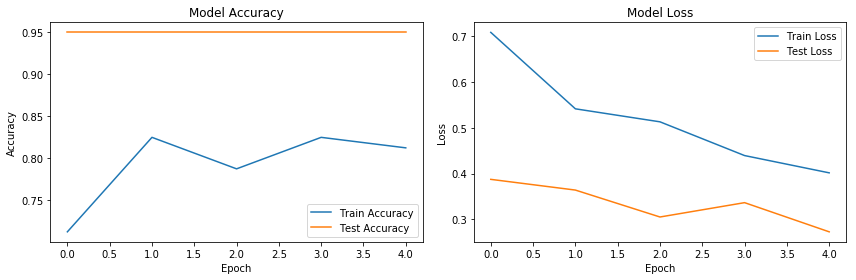

In [16]:
# Step 7: Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
# Step 6: Predict on a new video
def predict_deepfake(video_path, model):
    frames = extract_frames(video_path)
    if frames is None:
        return "Error: Could not process video."
    
    frames = np.expand_dims(frames, axis=0)
    prediction = model.predict(frames)[0][0]
    
    result = "Fake" if prediction > 0.5 else "Real"
    confidence = prediction if prediction > 0.5 else 1 - prediction
    return f"Prediction: {result}, Confidence: {confidence:.4f}"

# Update this after uploading your new video
NEW_VIDEO_PATH = '/kaggle/input/test-video-mp4/download.mp4'
print(predict_deepfake(NEW_VIDEO_PATH, model))

Prediction: Fake, Confidence: 0.8296


In [20]:
# Step 6: Predict on a new video
def predict_deepfake(video_path, model):
    frames = extract_frames(video_path)
    if frames is None:
        return "Error: Could not process video."
    
    frames = np.expand_dims(frames, axis=0)
    prediction = model.predict(frames)[0][0]
    
    result = "Fake" if prediction > 0.5 else "Real"
    confidence = prediction if prediction > 0.5 else 1 - prediction
    return f"Prediction: {result}, Confidence: {confidence:.4f}"

# Update this after uploading your new video
NEW_VIDEO_PATH = '/kaggle/input/testing2/download (1).mp4'
print(predict_deepfake(NEW_VIDEO_PATH, model))

Prediction: Fake, Confidence: 0.8110


In [21]:
# Step 6: Predict on a new video
def predict_deepfake(video_path, model):
    frames = extract_frames(video_path)
    if frames is None:
        return "Error: Could not process video."
    
    frames = np.expand_dims(frames, axis=0)
    prediction = model.predict(frames)[0][0]
    
    result = "Fake" if prediction > 0.5 else "Real"
    confidence = prediction if prediction > 0.5 else 1 - prediction
    return f"Prediction: {result}, Confidence: {confidence:.4f}"

# Update this after uploading your new video
NEW_VIDEO_PATH = '/kaggle/input/realvediotesting/videoplayback.mp4'
print(predict_deepfake(NEW_VIDEO_PATH, model))

Prediction: Fake, Confidence: 0.8277


In [22]:
# Step 6: Predict on a new video with detailed output
def predict_deepfake(video_path, model, threshold=0.5):
    frames = extract_frames(video_path)
    if frames is None:
        return "Error: Could not process video."
    
    frames = np.expand_dims(frames, axis=0)
    prediction = model.predict(frames, verbose=0)[0][0]
    
    result = "Fake" if prediction > threshold else "Real"
    confidence = prediction if prediction > threshold else 1 - prediction
    return f"Raw Score: {prediction:.4f}, Prediction: {result}, Confidence: {confidence:.4f}"

# Test your new video
NEW_VIDEO_PATH = '/kaggle/input/realvediotesting/videoplayback.mp4'  # Update this
print(predict_deepfake(NEW_VIDEO_PATH, model, threshold=0.5))

# Try different thresholds for debugging
for thresh in [0.3, 0.5, 0.7]:
    print(f"Threshold {thresh}: {predict_deepfake(NEW_VIDEO_PATH, model, threshold=thresh)}")

Raw Score: 0.8277, Prediction: Fake, Confidence: 0.8277
Threshold 0.3: Raw Score: 0.8277, Prediction: Fake, Confidence: 0.8277
Threshold 0.5: Raw Score: 0.8277, Prediction: Fake, Confidence: 0.8277
Threshold 0.7: Raw Score: 0.8277, Prediction: Fake, Confidence: 0.8277


In [10]:
import os
print(os.listdir('/kaggle/input/resnet-weights/'))

['resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5']
